### Assumptions

As with Pearson correlation (r), there are some assumptions concerning valid ANOVAs and t-tests:
- Normal distribution of the numeric variable for each group of the categorical variable 
- Equal variance of the numeric variable for each group of the categorical variable (note: variance = sqrt of std)
    - Note: if the sample size across the groups are close to equal, then this assumption is less important
- The data used to carry out the analyses were sampled independently between the groups
    - i. e. The data were randomly sampled across all possible group values. e.g. You didn't go to a women's conference to collect female samples and then a men's organization to collect male samples.
    - Note: if the group sample sizes are unequal, and variances are unequal, then use Welch's t-test.
 
t = (x1 - x2) / sqrt((s1^2)/n1 + (s2^2)/n2)

### ANOVA

Some categorical features will have 3 or many more groups. We could use a t-test to compare all pairs of groups of that categorical feature against some numeric label. But it makes more sense to use a measure that indicates whether there is a significant difference in means across all of the groups at onece. This is the purpose of an **analysis of variance (ANOVA)**, which refers to a collection of statistical models and their associated estimation procedures (e.g., the *variation* among categorical groups) used to analyze the differences among group means in a sample.

A *one-way* ANOVA is a certain type (the most simple) that is based on analyzing a bivariate relationship wih one categorical feature and one numeric label. Therefore, a one-way ANOVA will tell you whether there is a general difference across all groups (even if there are 3 or more) of that categorical feature. Other versions of ANOVA can test the effects of many categorical and numeric features at once on either one or many labels. 

In [52]:
from scipy import stats
import statistics as stat
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

edu_PartialHighSchool = [30000, 10000, 10000, 20000, 70000, 30000, 10000, 20000, 10000, 30000]
edu_HighSchool = [20000, 30000, 60000, 20000, 40000, 60000, 60000]
edu_PartialCollege = [60000, 40000, 30000, 130000, 60000, 40000]
edu_Bachelors = [40000, 20000, 90000, 120000, 60000, 130000, 20000, 100000, 80000, 30000, 100000, 120000]
edu_Graduate = [160000, 50000, 80000, 30000, 40000, 80000, 130000, 100000, 130000, 50000, 130000]

print(f"Partial High School: \t{int(stat.mean(edu_PartialHighSchool))}")
print(f"High School: \t\t{int(stat.mean(edu_HighSchool))}")
print(f"Partial College: \t{int(stat.mean(edu_PartialCollege))}")
print(f"Bachelors: \t\t{int(stat.mean(edu_Bachelors))}")
print(f"Graduate: \t\t{int(stat.mean(edu_Graduate))}")

Partial High School: 	24000
High School: 		41428
Partial College: 	60000
Bachelors: 		75833
Graduate: 		89090


In [54]:
t, p = stats.ttest_ind(edu_PartialHighSchool, edu_HighSchool)

print(f"t-value: {t}\np-value: {p}")

t-value: -1.9131753750607223
p-value: 0.07500898731578687


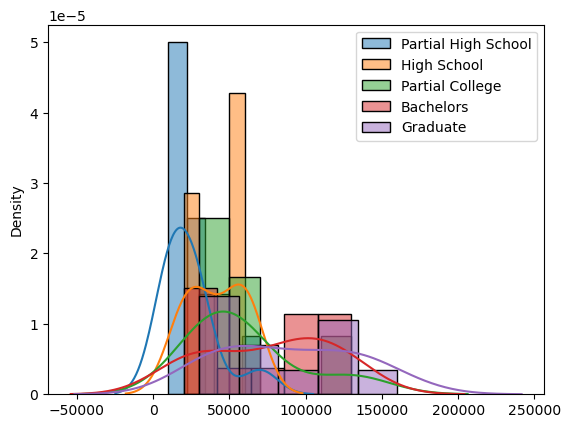

In [56]:
sns.histplot(edu_PartialHighSchool, label="Partial High School", kde=True, stat="density", kde_kws=dict(cut=3))
sns.histplot(edu_HighSchool, label="High School", kde=True, stat="density", kde_kws=dict(cut=3))
sns.histplot(edu_PartialCollege, label="Partial College", kde=True, stat="density", kde_kws=dict(cut=3))
sns.histplot(edu_Bachelors, label="Bachelors", kde=True, stat="density", kde_kws=dict(cut=3))
sns.histplot(edu_Graduate, label="Graduate", kde=True, stat="density", kde_kws=dict(cut=3))
plt.legend()
plt.show()

In [58]:
f, p = stats.f_oneway(edu_PartialHighSchool, edu_Bachelors, edu_Graduate, edu_HighSchool, edu_PartialCollege)

print(f"f-value: {f}\np-value: {p}")

f-value: 5.778065095961635
p-value: 0.0008781084858501968


In [60]:
df = pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


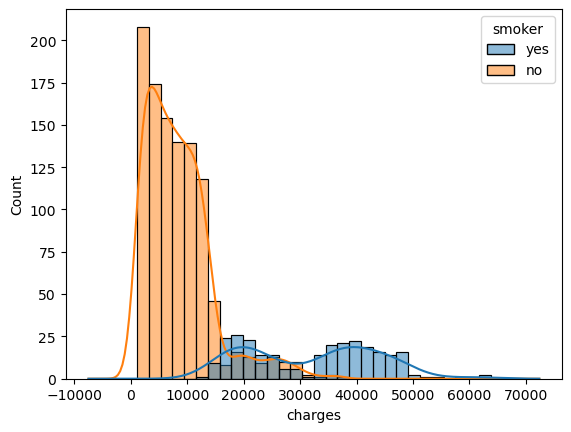

In [66]:
sns.histplot(data=df, x="charges", hue="smoker", kde=True, kde_kws=dict(cut=3));

In [72]:
smoker_y = df[df["smoker"] == "yes"]
smoker_n = df[df["smoker"] == "no"]

stats.ttest_ind(smoker_y["charges"], smoker_n["charges"])

TtestResult(statistic=46.66492117272371, pvalue=8.271435842179102e-283, df=1336.0)

In [84]:
feature = "smoker"
label = "charges"

groups = df[feature].unique()
grouped_values = []
for group in groups:
    grouped_values.append(df[df[feature] == group][label])

stats.f_oneway(*grouped_values) # * makes it like f_oneway(list1, list2), it separates different list members

F_onewayResult(statistic=2177.614868056519, pvalue=8.271435842182967e-283)

In [88]:
def anova(feature, label):
    groups = df[feature].unique()
    grouped_values = []
    for group in groups:
        grouped_values.append(df[df[feature] == group][label])

    return stats.f_oneway(*grouped_values)

In [90]:
anova("region", "charges")

F_onewayResult(statistic=2.96962669358912, pvalue=0.0308933560705201)

In [92]:
df = pd.read_csv("bike_buyers.csv")
df

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0,No
3,24381,Single,NaN,70000.0,0.0,Bachelors,Professional,Yes,1.0,5-10 Miles,Pacific,41.0,Yes
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,23731,Married,Male,60000.0,2.0,High School,Professional,Yes,2.0,2-5 Miles,North America,54.0,Yes
996,28672,Single,Male,70000.0,4.0,Graduate Degree,Professional,Yes,0.0,2-5 Miles,North America,35.0,Yes
997,11809,Married,NaN,60000.0,2.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,North America,38.0,Yes
998,19664,Single,Male,100000.0,3.0,Bachelors,Management,No,3.0,1-2 Miles,North America,38.0,No
